### Rohit Kumar-CS23B2053
### Sarvan Kumar-ME23B1065

# Advanced Vision-Language BraTS Segmentation

This notebook implements a state-of-the-art Multi-Modal architecture leveraging **BioViL-T**, **5-Slice Context Windows**, **Multi-Level FiLM Fusion**, **Cross-Attention Bottlenecks**, **Text-Guided Attention Gates (TGAG)**, and **Deep Supervision**


## 1. Setup & Imports
Importing PyTorch, HuggingFace Transformers, and defining Kaggle dataset paths.


In [1]:
import os, glob, json, re, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import cv2
import timm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial.distance import directed_hausdorff

IMG_ROOT = "/kaggle/input/datasets/hussainnasirkhan/flair-brats2020"
if os.path.exists(f"{IMG_ROOT}/FLAIR_BRATS2020_split"): IMG_ROOT = f"{IMG_ROOT}/FLAIR_BRATS2020_split"
TEXT_ROOT = "/kaggle/input/datasets/rohit45992/text-data"
OUT = "/kaggle/working/outputs"
os.makedirs(f"{OUT}/figures", exist_ok=True)
os.makedirs(f"{OUT}/models", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
BATCH = 16
EPOCHS = 20


## 2. Text Modality Processing
Loading paired radiology reports and linking them to their respective Patient IDs.


In [2]:
patient_to_text = {}
for txt_file in glob.glob(f"{TEXT_ROOT}/**/*.txt", recursive=True):
    pnum = re.findall(r"\d+", os.path.basename(txt_file))
    if pnum:
        with open(txt_file, "r", encoding="utf-8") as f:
            patient_to_text[str(int(pnum[-1]))] = f.read().strip()
print(f"Generated mapping for {len(patient_to_text)} patients")


Generated mapping for 369 patients


## 3. Advanced 5-Slice Dataloader
This customized PyTorch DataLoader utilizes a **5-slice volumetric context window** (t-2 to t+2) to provide the model with 3D structural awareness of the tumor, while mapping directly to BioViL-T tokenized clinical reports.


In [3]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedVLP-CXR-BERT-specialized", trust_remote_code=True)

class BraTSNpyDataset(Dataset):
    def __init__(self, img_dir, mask_dir, patient_to_text, img_size=224, every_n=2):
        self.img_size, self.patient_to_text = img_size, patient_to_text
        pairs = []
        for img_path in sorted(glob.glob(f"{img_dir}/*.npy")):
            base = os.path.basename(img_path)
            pnum = re.findall(r"\d+", base)
            if not pnum: continue
            for mc in [os.path.join(mask_dir, base.replace("image_","mask_")), os.path.join(mask_dir, f"mask_{pnum[-1]}.npy")]:
                if os.path.exists(mc): pairs.append((img_path, mc, int(pnum[-1]))); break
        self.vol_cache = {}
        for img_p, msk_p, pnum in tqdm(pairs, desc="Loading Volumes into RAM"):
            img = np.load(img_p).astype(np.float32)
            msk = np.load(msk_p).astype(np.float32)
            if msk.ndim == 4: msk = msk[..., 1:].max(axis=-1)
            self.vol_cache[pnum] = (img, msk)
        self.samples = []
        for img_p, msk_p, pnum in pairs:
            msk = self.vol_cache[pnum][1]
            for s in range(0, msk.shape[-1], every_n):
                if msk[:,:,s].sum() > 50: self.samples.append((pnum, s))
                
    def __len__(self): return len(self.samples)
    
    def __getitem__(self, idx):
        pnum, si = self.samples[idx]
        img_vol, msk_vol = self.vol_cache[pnum]
        n = img_vol.shape[2]
        slices = [max(si-2,0), max(si-1,0), si, min(si+1,n-1), min(si+2,n-1)]
        img = np.stack([img_vol[:,:,s] for s in slices], axis=0)
        mask = msk_vol[:,:,si]
        for c in range(5):
            nz = img[c][img[c]>0]
            if nz.size>0: img[c]=(img[c]-nz.mean())/(nz.std()+1e-8)
        
        img = torch.tensor(img, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)
        img = F.interpolate(img.unsqueeze(0), size=(self.img_size,self.img_size), mode="bilinear").squeeze(0)
        mask = F.interpolate(mask.unsqueeze(0).unsqueeze(0), size=(self.img_size,self.img_size), mode="nearest").squeeze(0)
        text = self.patient_to_text.get(str(pnum), "Brain MRI FLAIR scan.")
        return img, mask, text

def collate(batch):
    imgs, masks, texts = zip(*batch)
    enc = tokenizer(list(texts), padding="max_length", truncation=True, max_length=128, return_tensors="pt")
    return torch.stack(imgs), torch.stack(masks), enc

train_ds = BraTSNpyDataset(f"{IMG_ROOT}/train/images", f"{IMG_ROOT}/train/masks", patient_to_text, every_n=2)
val_ds = BraTSNpyDataset(f"{IMG_ROOT}/val/images", f"{IMG_ROOT}/val/masks", patient_to_text, every_n=2)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, collate_fn=collate, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0, collate_fn=collate, pin_memory=True)


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

configuration_cxrbert.py:   0%|          | 0.00/889 [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/BiomedVLP-CXR-BERT-specialized:
- configuration_cxrbert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Loading Volumes into RAM:   0%|          | 0/258 [00:00<?, ?it/s]

Loading Volumes into RAM:   0%|          | 0/86 [00:00<?, ?it/s]

## 3.5 Sample Visualization
Let's visualize a few training samples along with their corresponding text descriptions to verify the dataloader.


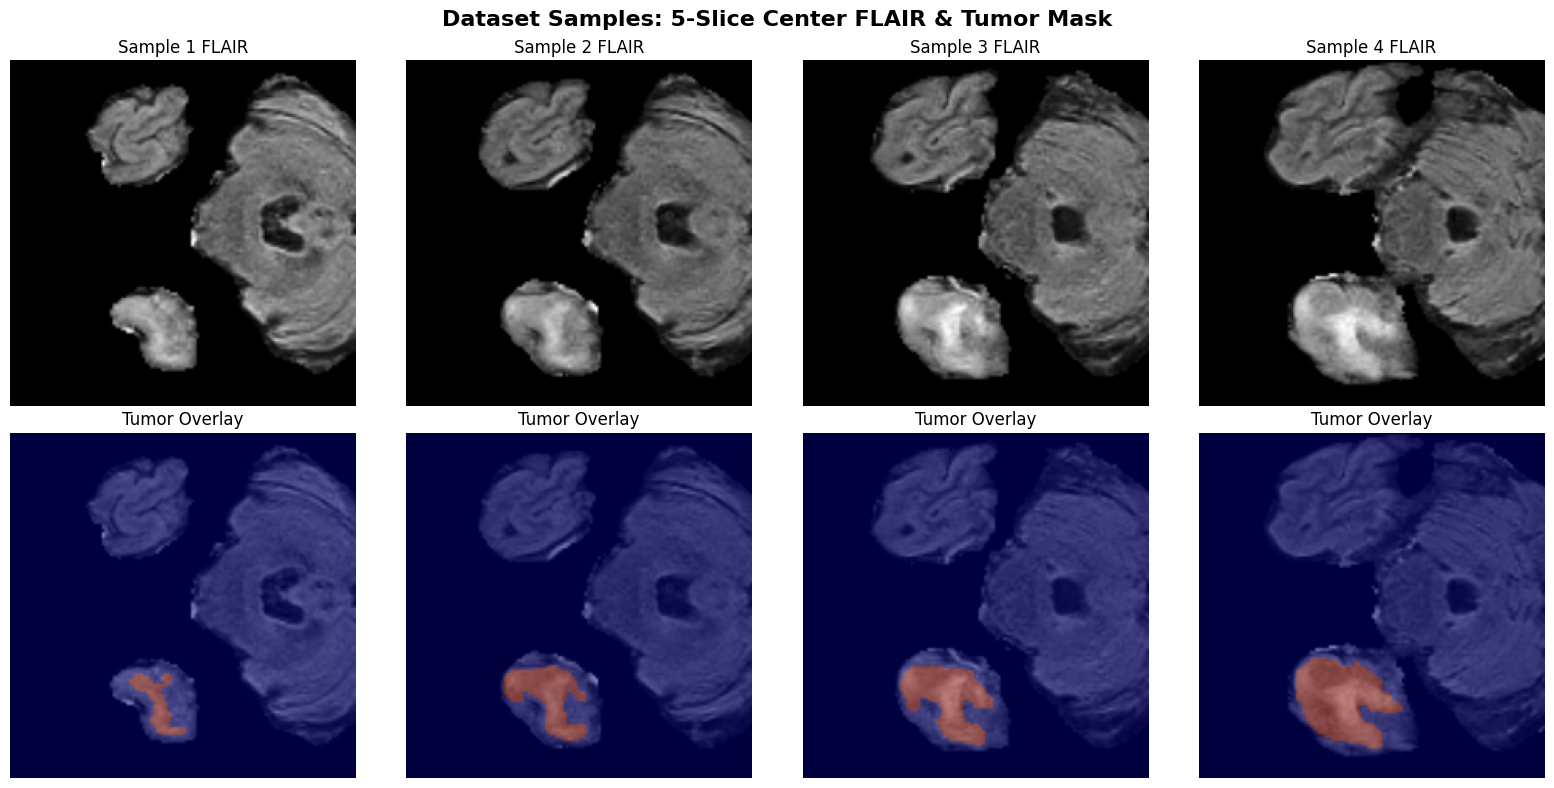

In [4]:
sample_imgs, sample_masks, sample_texts = next(iter(val_loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Dataset Samples: 5-Slice Center FLAIR & Tumor Mask', fontsize=16, fontweight='bold')

for i in range(4):
    img = sample_imgs[i, 2].numpy() # Center slice of the 5-stack
    mask = sample_masks[i, 0].numpy()
    
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"Sample {i+1} FLAIR")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].imshow(mask, cmap='jet', alpha=0.5)
    axes[1, i].set_title("Tumor Overlay")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


## 4. Multi-Modal Architecture
Implementation of the **Text Encoder (BioViL-T)**, **FiLMFusion**, **CrossAttentionFusion**, **Text-Guided Attention Gates**, and **Deep Supervision**.


In [5]:
class TextEncoder(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.bert = AutoModel.from_pretrained('microsoft/BiomedVLP-CXR-BERT-specialized', trust_remote_code=True)
        # Unfreeze last 4 layers for domain adaptation
        for name, param in self.bert.named_parameters():
            if 'encoder.layer.8' in name or 'encoder.layer.9' in name or 'encoder.layer.10' in name or 'encoder.layer.11' in name or 'pooler' in name:
                param.requires_grad = True
            else:
                param.requires_grad = False
        self.proj = nn.Sequential(nn.Linear(768, 512), nn.GELU(), nn.Dropout(0.1), nn.Linear(512, out_dim))
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb = self.proj(out.last_hidden_state[:,0,:])
        seq_emb = self.proj(out.last_hidden_state)
        return cls_emb, seq_emb

class FiLMFusion(nn.Module):
    def __init__(self, img_channels, text_dim):
        super().__init__()
        self.gamma = nn.Linear(text_dim, img_channels)
        self.beta = nn.Linear(text_dim, img_channels)
        nn.init.zeros_(self.gamma.weight)
        nn.init.zeros_(self.beta.weight)
        nn.init.ones_(self.gamma.bias)
        nn.init.zeros_(self.beta.bias)
    def forward(self, img_feat, text_cls):
        g = self.gamma(text_cls).unsqueeze(-1).unsqueeze(-1)
        b = self.beta(text_cls).unsqueeze(-1).unsqueeze(-1)
        return g * img_feat + b

class CrossAttentionFusion(nn.Module):
    def __init__(self, img_channels, text_dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=img_channels, num_heads=8, batch_first=True)
        self.norm = nn.LayerNorm(img_channels)
        self.text_proj = nn.Linear(text_dim, img_channels)
    def forward(self, img_feat, text_seq):
        B, C, H, W = img_feat.shape
        img_q = img_feat.flatten(2).transpose(1, 2)
        text_kv = self.text_proj(text_seq)
        attn_out, _ = self.attn(img_q, text_kv, text_kv)
        out = self.norm(img_q + attn_out).transpose(1, 2).reshape(B, C, H, W)
        return out

class TextGuidedAttentionGate(nn.Module):
    def __init__(self, gate_ch, skip_ch, inter_ch, text_dim=None):
        super().__init__()
        self.W_gate=nn.Sequential(nn.Conv2d(gate_ch,inter_ch,1),nn.BatchNorm2d(inter_ch))
        self.W_skip=nn.Sequential(nn.Conv2d(skip_ch,inter_ch,1),nn.BatchNorm2d(inter_ch))
        self.W_text=nn.Linear(text_dim, inter_ch) if text_dim else None
        self.psi=nn.Sequential(nn.Conv2d(inter_ch,1,1),nn.BatchNorm2d(1),nn.Sigmoid())
        self.relu=nn.ReLU(False)
    def forward(self, gate, skip, text_cls=None):
        g=self.W_gate(gate); s=self.W_skip(skip)
        if g.shape[2:]!=s.shape[2:]: g=F.interpolate(g,size=s.shape[2:],mode='bilinear',align_corners=False)
        feat = g + s
        if self.W_text is not None and text_cls is not None:
            t = self.W_text(text_cls).unsqueeze(-1).unsqueeze(-1)
            feat = feat + t
        return skip*self.psi(self.relu(feat))

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, use_attn_gate=True, text_dim=None):
        super().__init__()
        self.up=nn.ConvTranspose2d(in_ch,in_ch//2,kernel_size=2,stride=2)
        self.attn_gate=TextGuidedAttentionGate(in_ch//2,skip_ch,skip_ch//2, text_dim) if use_attn_gate else None
        cat_ch=in_ch//2+skip_ch
        self.conv=nn.Sequential(
            nn.Conv2d(cat_ch,out_ch,3,padding=1),nn.BatchNorm2d(out_ch),nn.ReLU(False),
            nn.Conv2d(out_ch,out_ch,3,padding=1),nn.BatchNorm2d(out_ch),nn.ReLU(False))
    def forward(self, x, skip, text_cls=None):
        x=self.up(x)
        if x.shape[2:]!=skip.shape[2:]: x=F.interpolate(x,size=skip.shape[2:],mode='bilinear',align_corners=False)
        if self.attn_gate: skip=self.attn_gate(x,skip,text_cls)
        return self.conv(torch.cat([x,skip],dim=1))

class TGSwinUNet(nn.Module):
    def __init__(self, num_classes=1, text_dim=256, img_size=224):
        super().__init__()
        self.img_size=img_size
        self.slice_conv = nn.Conv2d(5, 3, 1)
        self.encoder=timm.create_model('swin_tiny_patch4_window7_224',pretrained=True,in_chans=3,features_only=True,out_indices=(0,1,2,3))
        self.text_encoder=TextEncoder(out_dim=text_dim)
        
        self.film0 = FiLMFusion(96, text_dim)
        self.film1 = FiLMFusion(192, text_dim)
        self.film2 = FiLMFusion(384, text_dim)
        self.cross_attn = CrossAttentionFusion(768, text_dim)
        
        self.dec4=DecoderBlock(768,384,256, text_dim=text_dim)
        self.dec3=DecoderBlock(256,192,128, text_dim=text_dim)
        self.dec2=DecoderBlock(128,96,64, text_dim=text_dim)
        
        self.final_up=nn.Sequential(nn.ConvTranspose2d(64,32,kernel_size=4,stride=4),nn.BatchNorm2d(32),nn.ReLU(False),nn.Conv2d(32,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(False))
        self.seg_head=nn.Conv2d(32,num_classes,1)
        
        # Deep Supervision Heads
        self.ds4 = nn.Conv2d(256, num_classes, 1)
        self.ds3 = nn.Conv2d(128, num_classes, 1)
    
    def _to_bchw(self, f):
        if f.dim()==4 and f.shape[1]>f.shape[-1]: return f
        return f.permute(0,3,1,2) if f.dim()==4 else f
    
    def forward(self, img, input_ids, attention_mask):
        img_3c = self.slice_conv(img)
        feats=[self._to_bchw(f) for f in self.encoder(img_3c)]
        cls_emb, seq_emb = self.text_encoder(input_ids, attention_mask)
        
        f0 = self.film0(feats[0], cls_emb)
        f1 = self.film1(feats[1], cls_emb)
        f2 = self.film2(feats[2], cls_emb)
        f3 = self.cross_attn(feats[3], seq_emb)
        
        d4=self.dec4(f3, f2, cls_emb)
        d3=self.dec3(d4, f1, cls_emb)
        d2=self.dec2(d3, f0, cls_emb)
        
        out=self.final_up(d2)
        out=F.interpolate(out,size=self.img_size,mode='bilinear',align_corners=False)
        
        img_global = F.adaptive_avg_pool2d(feats[3], 1).flatten(1)
        
        if self.training:
            out4 = F.interpolate(self.ds4(d4), size=self.img_size, mode='bilinear')
            out3 = F.interpolate(self.ds3(d3), size=self.img_size, mode='bilinear')
            return self.seg_head(out), out4, out3, cls_emb, img_global
        else:
            return self.seg_head(out), cls_emb, img_global

class SwinUNetImageOnly(nn.Module):
    def __init__(self, num_classes=1, img_size=224):
        super().__init__()
        self.img_size=img_size
        self.slice_conv = nn.Conv2d(5, 3, 1)
        self.encoder=timm.create_model('swin_tiny_patch4_window7_224',pretrained=True,in_chans=3,features_only=True,out_indices=(0,1,2,3))
        self.dec4=DecoderBlock(768,384,256)
        self.dec3=DecoderBlock(256,192,128)
        self.dec2=DecoderBlock(128,96,64)
        self.final_up=nn.Sequential(nn.ConvTranspose2d(64,32,kernel_size=4,stride=4),nn.BatchNorm2d(32),nn.ReLU(False),nn.Conv2d(32,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(False))
        self.seg_head=nn.Conv2d(32,num_classes,1)
    def _to_bchw(self,f):
        if f.dim()==4 and f.shape[1]>f.shape[-1]: return f
        return f.permute(0,3,1,2) if f.dim()==4 else f
    def forward(self, img):
        img_3c = self.slice_conv(img)
        enc=[self._to_bchw(f) for f in self.encoder(img_3c)]
        d4=self.dec4(enc[3],enc[2]); d3=self.dec3(d4,enc[1]); d2=self.dec2(d3,enc[0])
        out=self.final_up(d2)
        out=F.interpolate(out,size=self.img_size,mode='bilinear',align_corners=False)
        return self.seg_head(out)


## 5. Loss Functions & Metrics
Computing Dice, Focal, Boundary, Contrastive Alignment Loss, and Evaluation Metrics including **Hausdorff Distance**.


In [6]:
class DiceLoss(nn.Module):
    def forward(self, p, t):
        p=torch.sigmoid(p); i=(p*t).sum(dim=(2,3)); u=p.sum(dim=(2,3))+t.sum(dim=(2,3))
        return 1 - (2.*i+1.)/(u+1.)
class FocalLoss(nn.Module):
    def forward(self, p, t):
        p=torch.sigmoid(p); ce=F.binary_cross_entropy_with_logits(p,t,reduction='none')
        pt=p*t+(1-p)*(1-t); return (0.25*((1-pt)**2)*ce).mean()

def boundary_loss(pred, target):
    target_pool = F.max_pool2d(target, kernel_size=3, stride=1, padding=1)
    boundary = target_pool - target
    bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
    return (bce * (1 + 5 * boundary)).mean()

def contrastive_loss(img_emb, text_emb, temp=0.07):
    if img_emb.shape[-1] != text_emb.shape[-1]:
        proj = nn.Linear(img_emb.shape[-1], text_emb.shape[-1]).to(img_emb.device)
        img_emb = proj(img_emb)
    img_emb = F.normalize(img_emb, dim=-1)
    text_emb = F.normalize(text_emb, dim=-1)
    logits = (img_emb @ text_emb.T) / temp
    labels = torch.arange(logits.size(0)).to(logits.device)
    return F.cross_entropy(logits, labels)

def dice_score(pred, target, thr=0.5):
    p = (torch.sigmoid(pred) > thr).float(); s = 1.
    i = (p * target).sum()
    return (2 * i + s) / (p.sum() + target.sum() + s)

def iou_score(pred, target, thr=0.5):
    p = (torch.sigmoid(pred) > thr).float(); s = 1.
    i = (p * target).sum()
    u = p.sum() + target.sum() - i
    return (i + s) / (u + s)

def hausdorff_distance_metric(pred, target, thr=0.5):
    p = (torch.sigmoid(pred) > thr).squeeze().cpu().numpy()
    t = target.squeeze().cpu().numpy()
    if p.sum() == 0 and t.sum() == 0: return 0.0
    if p.sum() == 0 or t.sum() == 0: return 50.0 # Penalty for complete miss
    p_coords = np.column_stack(np.where(p > 0))
    t_coords = np.column_stack(np.where(t > 0))
    d1 = directed_hausdorff(p_coords, t_coords)[0]
    d2 = directed_hausdorff(t_coords, p_coords)[0]
    return max(d1, d2)


## 6. Training Logic (Section 6.1)
Executing training loops to generate **Loss vs Epoch**, **Dice Score vs Epoch**, and **IoU vs Epoch**.


In [7]:
def train_img_only(model, epochs=EPOCHS):
    print('\n=== Training Image-Only Baseline ===')
    opt = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
    scaler = torch.amp.GradScaler('cuda')
    dl, fl = DiceLoss(), FocalLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_dice = 0; history = {'loss':[], 'dice':[], 'iou':[]}
    
    for ep in range(epochs):
        model.train(); epoch_loss = 0
        for imgs, masks, _ in tqdm(train_loader, leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                pred = model(imgs)
                loss = dl(pred, masks).mean() + fl(pred, masks) + 0.2*boundary_loss(pred, masks)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            epoch_loss += loss.item()
        scheduler.step()
            
        model.eval(); vd = 0; vi = 0
        with torch.no_grad():
            for imgs, masks, _ in val_loader:
                pred = model(imgs.to(DEVICE))
                vd += dice_score(pred, masks.to(DEVICE)).item()
                vi += iou_score(pred, masks.to(DEVICE)).item()
        vd /= len(val_loader); vi /= len(val_loader); epoch_loss /= len(train_loader)
        history['loss'].append(epoch_loss); history['dice'].append(vd); history['iou'].append(vi)
        print(f'Epoch {ep+1} | Loss: {epoch_loss:.4f} | Val Dice: {vd:.4f} | Val IoU: {vi:.4f}')
        if vd > best_dice:
            best_dice = vd; torch.save(model.state_dict(), f'{OUT}/models/img_only.pth')
    print(f'Best Image-Only Dice: {best_dice:.4f}')
    return history

def train_mm(model, epochs=EPOCHS):
    print('\n=== Training Multi-Modal TG-SwinUNet (with Deep Supervision) ===')
    text_params = [p for n, p in model.named_parameters() if 'text_encoder.bert' in n and p.requires_grad]
    base_params = [p for n, p in model.named_parameters() if 'text_encoder.bert' not in n and p.requires_grad]
    opt = torch.optim.AdamW([{'params': base_params}, {'params': text_params, 'lr': 1e-5}], lr=1e-4, weight_decay=1e-5)
    
    scaler = torch.amp.GradScaler('cuda')
    dl, fl = DiceLoss(), FocalLoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_dice = 0; history = {'loss':[], 'dice':[], 'iou':[]}
    
    for ep in range(epochs):
        model.train(); epoch_loss = 0
        for imgs, masks, texts in tqdm(train_loader, leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            ids, am = texts['input_ids'].to(DEVICE), texts['attention_mask'].to(DEVICE)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                pred, out4, out3, cls_emb, img_global = model(imgs, ids, am)
                seg_loss = (dl(pred, masks).mean() + fl(pred, masks) +
                            0.5 * (dl(out3, masks).mean() + fl(out3, masks)) +
                            0.25 * (dl(out4, masks).mean() + fl(out4, masks)))
                bl_loss = 0.2 * boundary_loss(pred, masks)
                cl_loss = 0.1 * contrastive_loss(img_global, cls_emb)
                loss = seg_loss + bl_loss + cl_loss
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            epoch_loss += loss.item()
        scheduler.step()
            
        model.eval(); vd = 0; vi = 0
        with torch.no_grad():
            for imgs, masks, texts in val_loader:
                pred, _, _ = model(imgs.to(DEVICE), texts['input_ids'].to(DEVICE), texts['attention_mask'].to(DEVICE))
                vd += dice_score(pred, masks.to(DEVICE)).item()
                vi += iou_score(pred, masks.to(DEVICE)).item()
        vd /= len(val_loader); vi /= len(val_loader); epoch_loss /= len(train_loader)
        history['loss'].append(epoch_loss); history['dice'].append(vd); history['iou'].append(vi)
        print(f'Epoch {ep+1} | Loss: {epoch_loss:.4f} | Val Dice: {vd:.4f} | Val IoU: {vi:.4f}')
        if vd > best_dice:
            best_dice = vd; torch.save(model.state_dict(), f'{OUT}/models/tg_mm.pth')
    print(f'Best MM Dice: {best_dice:.4f}')
    return history


In [8]:
main_model = TGSwinUNet().to(DEVICE)
img_model = SwinUNetImageOnly().to(DEVICE)

print("Starting Execution...")
hist_img = train_img_only(img_model)
hist_mm = train_mm(main_model)


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

modeling_cxrbert.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/BiomedVLP-CXR-BERT-specialized:
- modeling_cxrbert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

...

Epoch 18 | Loss: 0.4137 | Val Dice: 0.8913 | Val IoU: 0.8121


  0%|          | 0/509 [00:00<?, ?it/s]

Epoch 19 | Loss: 0.4126 | Val Dice: 0.8922 | Val IoU: 0.8133


  0%|          | 0/509 [00:00<?, ?it/s]

Epoch 20 | Loss: 0.4117 | Val Dice: 0.8925 | Val IoU: 0.8138
Best MM Dice: 0.8940


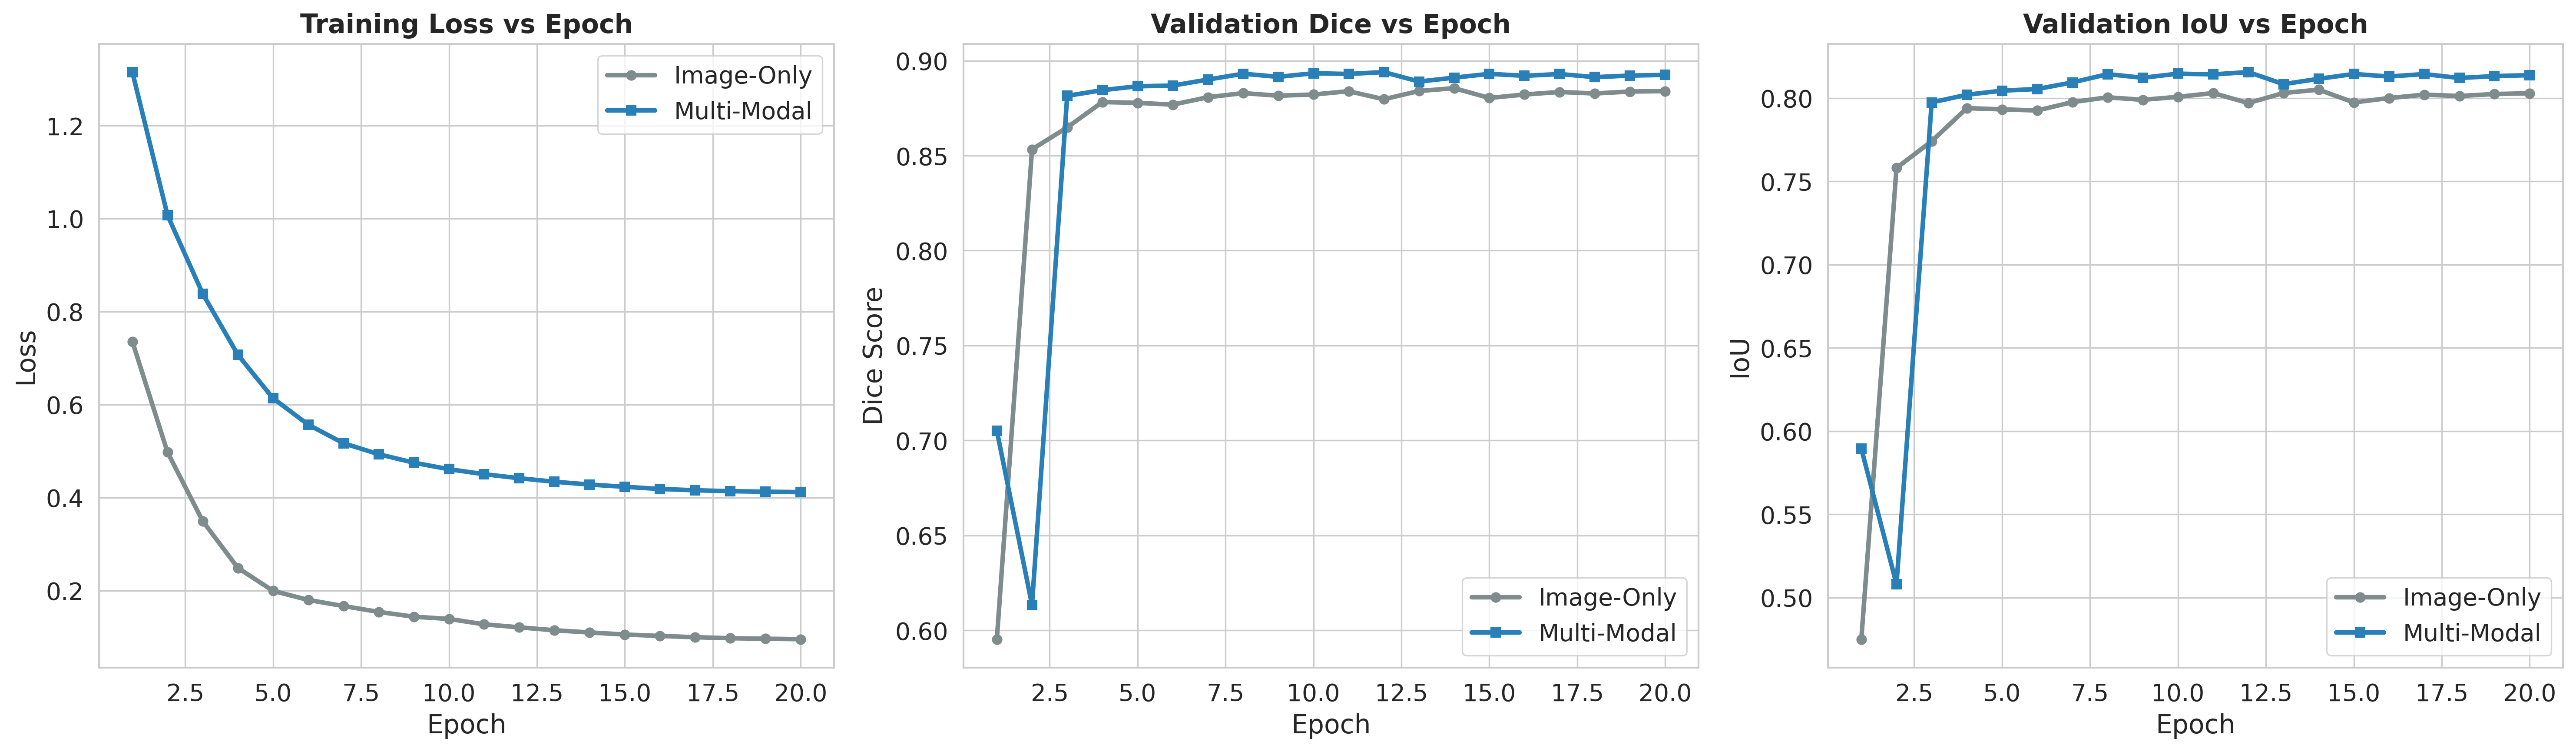

In [9]:
sns.set_theme(style='whitegrid', context='paper', font_scale=1.5)
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=300)
epochs_range = range(1, EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, hist_img['loss'], label='Image-Only', color='#7f8c8d', linewidth=2.5, marker='o')
axes[0].plot(epochs_range, hist_mm['loss'], label='Multi-Modal', color='#2980b9', linewidth=2.5, marker='s')
axes[0].set_title('Training Loss vs Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

# Dice
axes[1].plot(epochs_range, hist_img['dice'], label='Image-Only', color='#7f8c8d', linewidth=2.5, marker='o')
axes[1].plot(epochs_range, hist_mm['dice'], label='Multi-Modal', color='#2980b9', linewidth=2.5, marker='s')
axes[1].set_title('Validation Dice vs Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Dice Score')
axes[1].legend()

# IoU
axes[2].plot(epochs_range, hist_img['iou'], label='Image-Only', color='#7f8c8d', linewidth=2.5, marker='o')
axes[2].plot(epochs_range, hist_mm['iou'], label='Multi-Modal', color='#2980b9', linewidth=2.5, marker='s')
axes[2].set_title('Validation IoU vs Epoch', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('IoU')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUT}/figures/training_curves.png')
plt.show()


## 7. Evaluation Metrics & Ablation Study (Section 6.4)
Compare performance of model without text input and model with text input (Dice, IoU, Hausdorff, Precision, Recall).


Generating comprehensive metrics on Validation Set...


  0%|          | 0/174 [00:00<?, ?it/s]

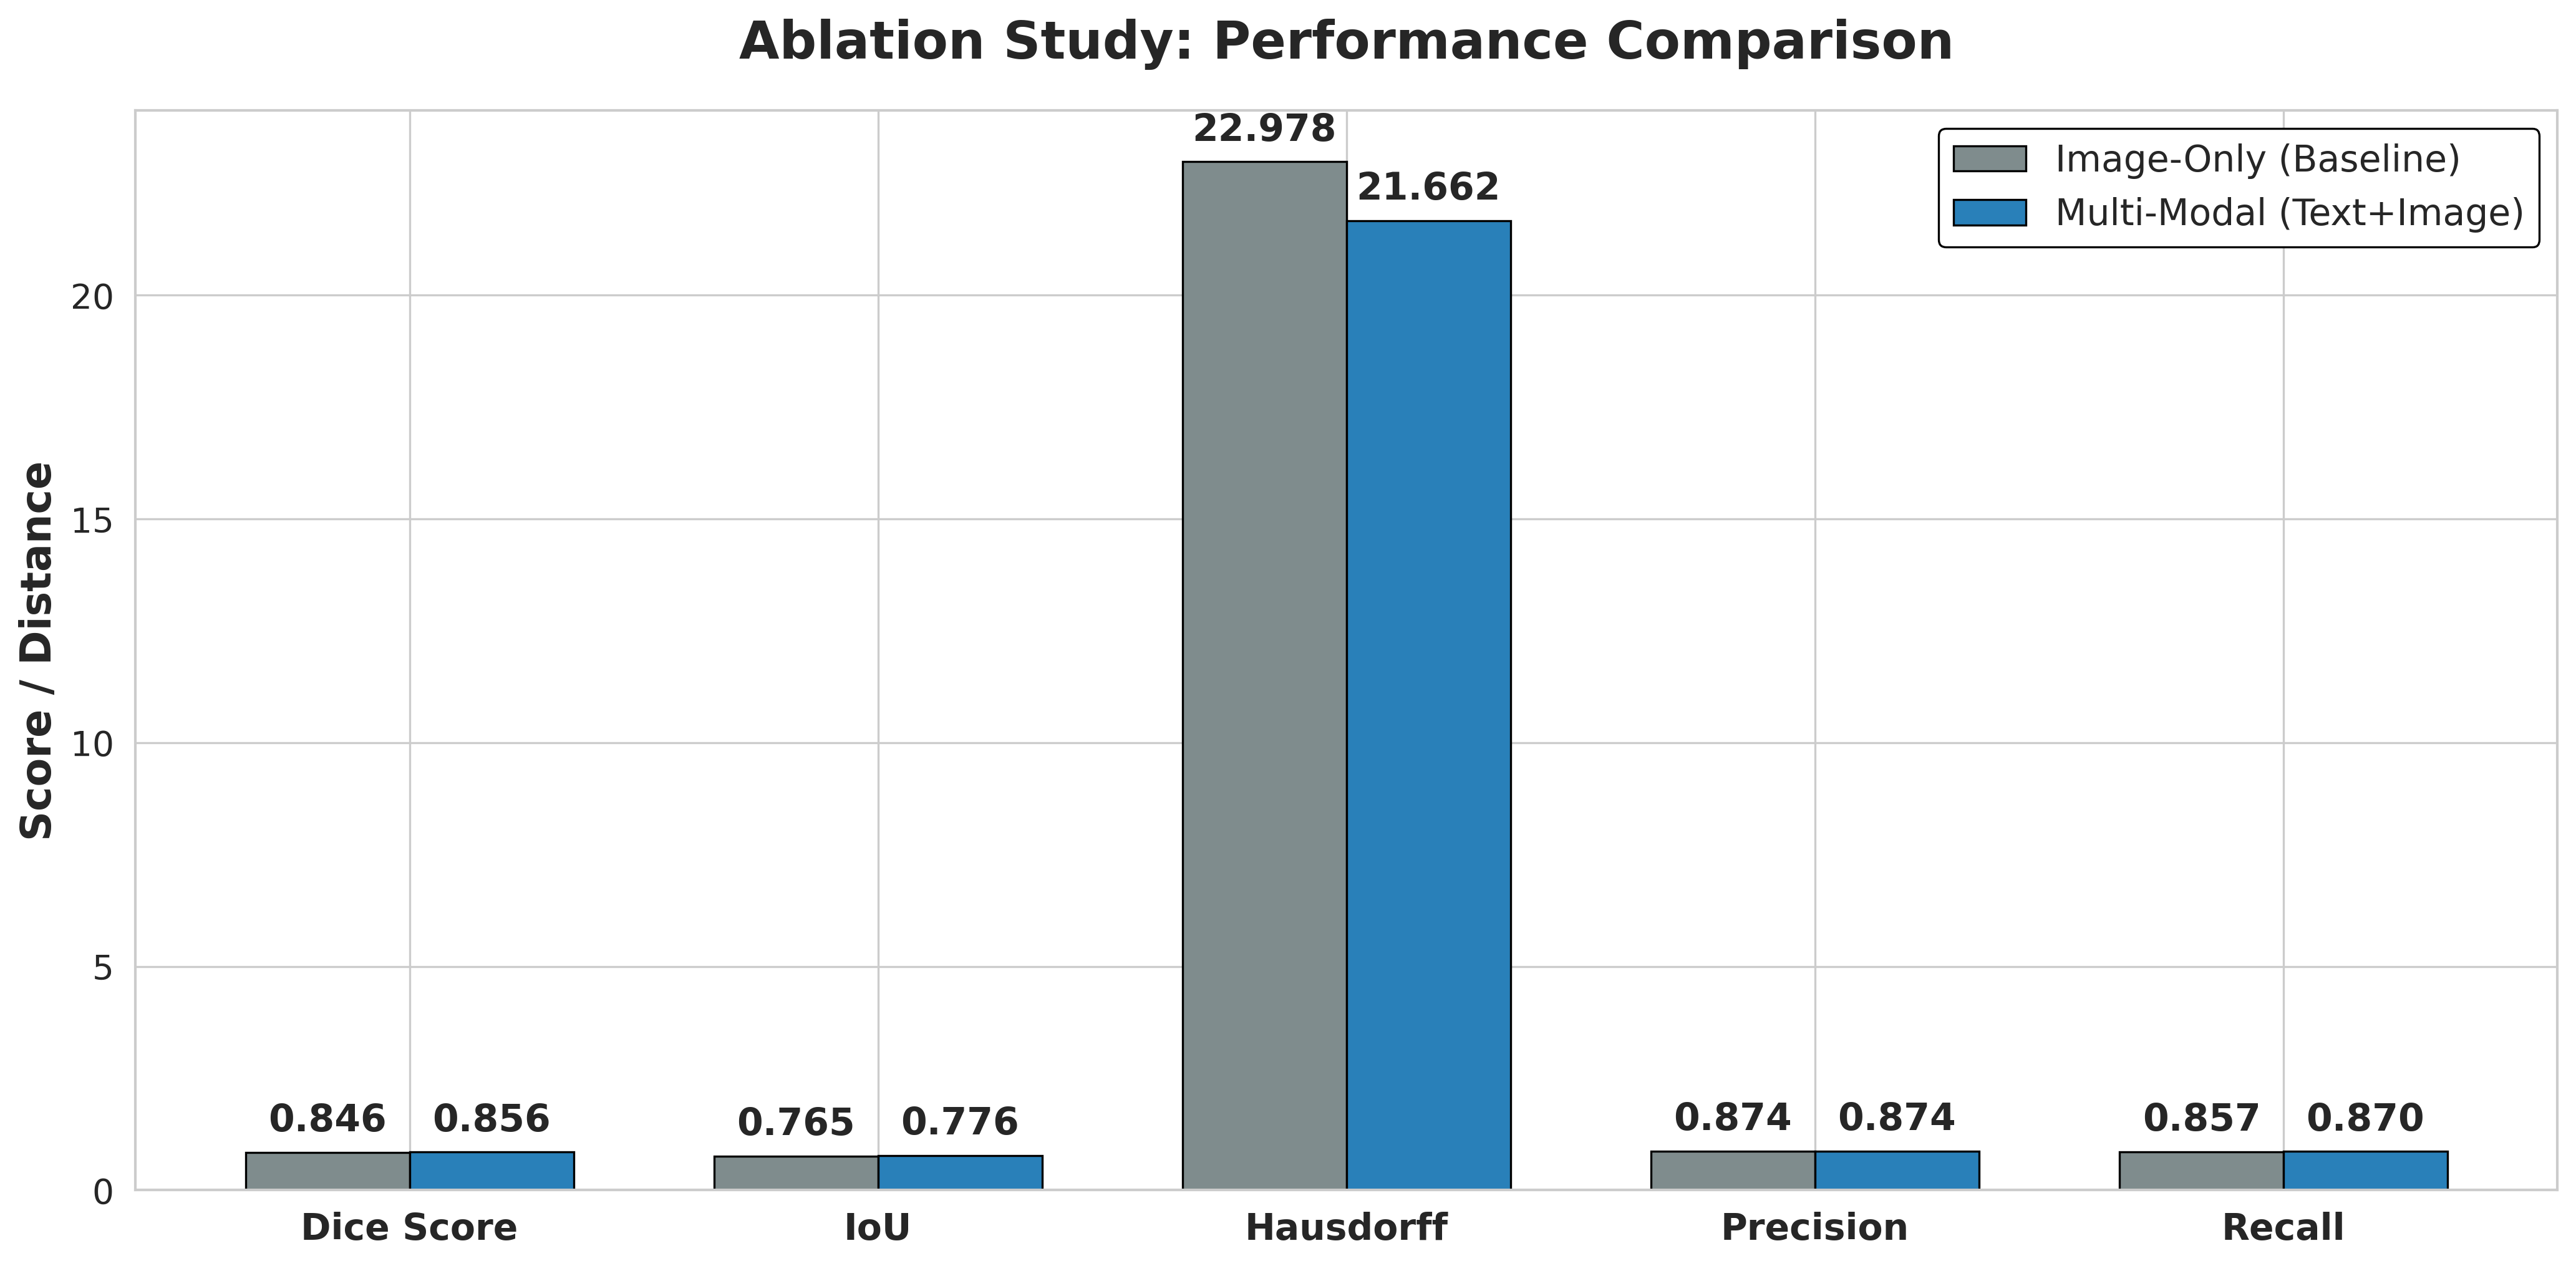

In [10]:
def precision_recall(pred, target):
    tp = (pred * target).sum().item()
    fp = (pred * (1 - target)).sum().item()
    fn = ((1 - pred) * target).sum().item()
    return tp / (tp + fp + 1e-8), tp / (tp + fn + 1e-8)

main_model.load_state_dict(torch.load(f"{OUT}/models/tg_mm.pth"))
img_model.load_state_dict(torch.load(f"{OUT}/models/img_only.pth"))
main_model.eval(); img_model.eval()

rmm, rimg = [], []
ie, te2 = [], []

print('Generating comprehensive metrics on Validation Set...')
with torch.no_grad():
    for imgs, masks, texts in tqdm(val_loader):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        ids, am = texts['input_ids'].to(DEVICE), texts['attention_mask'].to(DEVICE)
        
        lo_mm, cls_emb, _ = main_model(imgs, ids, am)
        p_mm = (torch.sigmoid(lo_mm) > 0.5).float()
        
        lo_img = img_model(imgs)
        p_img = (torch.sigmoid(lo_img) > 0.5).float()
        
        for b in range(imgs.shape[0]):
            d_mm = dice_score(lo_mm[b:b+1], masks[b:b+1]).item()
            i_mm = iou_score(lo_mm[b:b+1], masks[b:b+1]).item()
            h_mm = hausdorff_distance_metric(lo_mm[b:b+1], masks[b:b+1])
            pr_mm, rc_mm = precision_recall(p_mm[b,0], masks[b,0])
            rmm.append({'dice': d_mm, 'iou': i_mm, 'hausdorff': h_mm, 'precision': pr_mm, 'recall': rc_mm, 'img': imgs[b,2].cpu(), 'gt': masks[b,0].cpu(), 'pred': p_mm[b,0].cpu()})
            
            d_im = dice_score(lo_img[b:b+1], masks[b:b+1]).item()
            i_im = iou_score(lo_img[b:b+1], masks[b:b+1]).item()
            h_im = hausdorff_distance_metric(lo_img[b:b+1], masks[b:b+1])
            pr_im, rc_im = precision_recall(p_img[b,0], masks[b,0])
            rimg.append({'dice': d_im, 'iou': i_im, 'hausdorff': h_im, 'precision': pr_im, 'recall': rc_im})
            
        te2.append(cls_emb.cpu())
        img_3c = main_model.slice_conv(imgs)
        feats = main_model.encoder(img_3c)
        bot = feats[-1]
        if bot.dim()==4 and bot.shape[1]<=bot.shape[-1]: bot=bot.permute(0,3,1,2)
        ie.append(F.adaptive_avg_pool2d(bot, 1).squeeze(-1).squeeze(-1).cpu())

df_mm = pd.DataFrame(rmm)
df_img = pd.DataFrame(rimg)

metrics = ['dice', 'iou', 'hausdorff', 'precision', 'recall']
labels = ['Dice Score', 'IoU', 'Hausdorff', 'Precision', 'Recall']
x = np.arange(len(metrics)); width = 0.35

fig, ax = plt.subplots(figsize=(14, 7), dpi=300)
rects1 = ax.bar(x - width/2, [df_img[m].mean() for m in metrics], width, label='Image-Only (Baseline)', color='#7f8c8d', edgecolor='black')
rects2 = ax.bar(x + width/2, [df_mm[m].mean() for m in metrics], width, label='Multi-Modal (Text+Image)', color='#2980b9', edgecolor='black')

ax.set_ylabel('Score / Distance', fontsize=16, fontweight='bold')
ax.set_title('Ablation Study: Performance Comparison', fontsize=20, fontweight='bold', pad=20)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=14, fontweight='bold')
ax.legend(fontsize=14, loc='upper right', framealpha=1.0, edgecolor='black')

for rects in [rects1, rects2]:
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width() / 2, h), xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/figures/ablation_study.png')
plt.show()


## 8. Error Analysis & Failure Cases (Section 6.6)
Dice score distribution and Visualization of Failure Cases (Dice < 0.6).


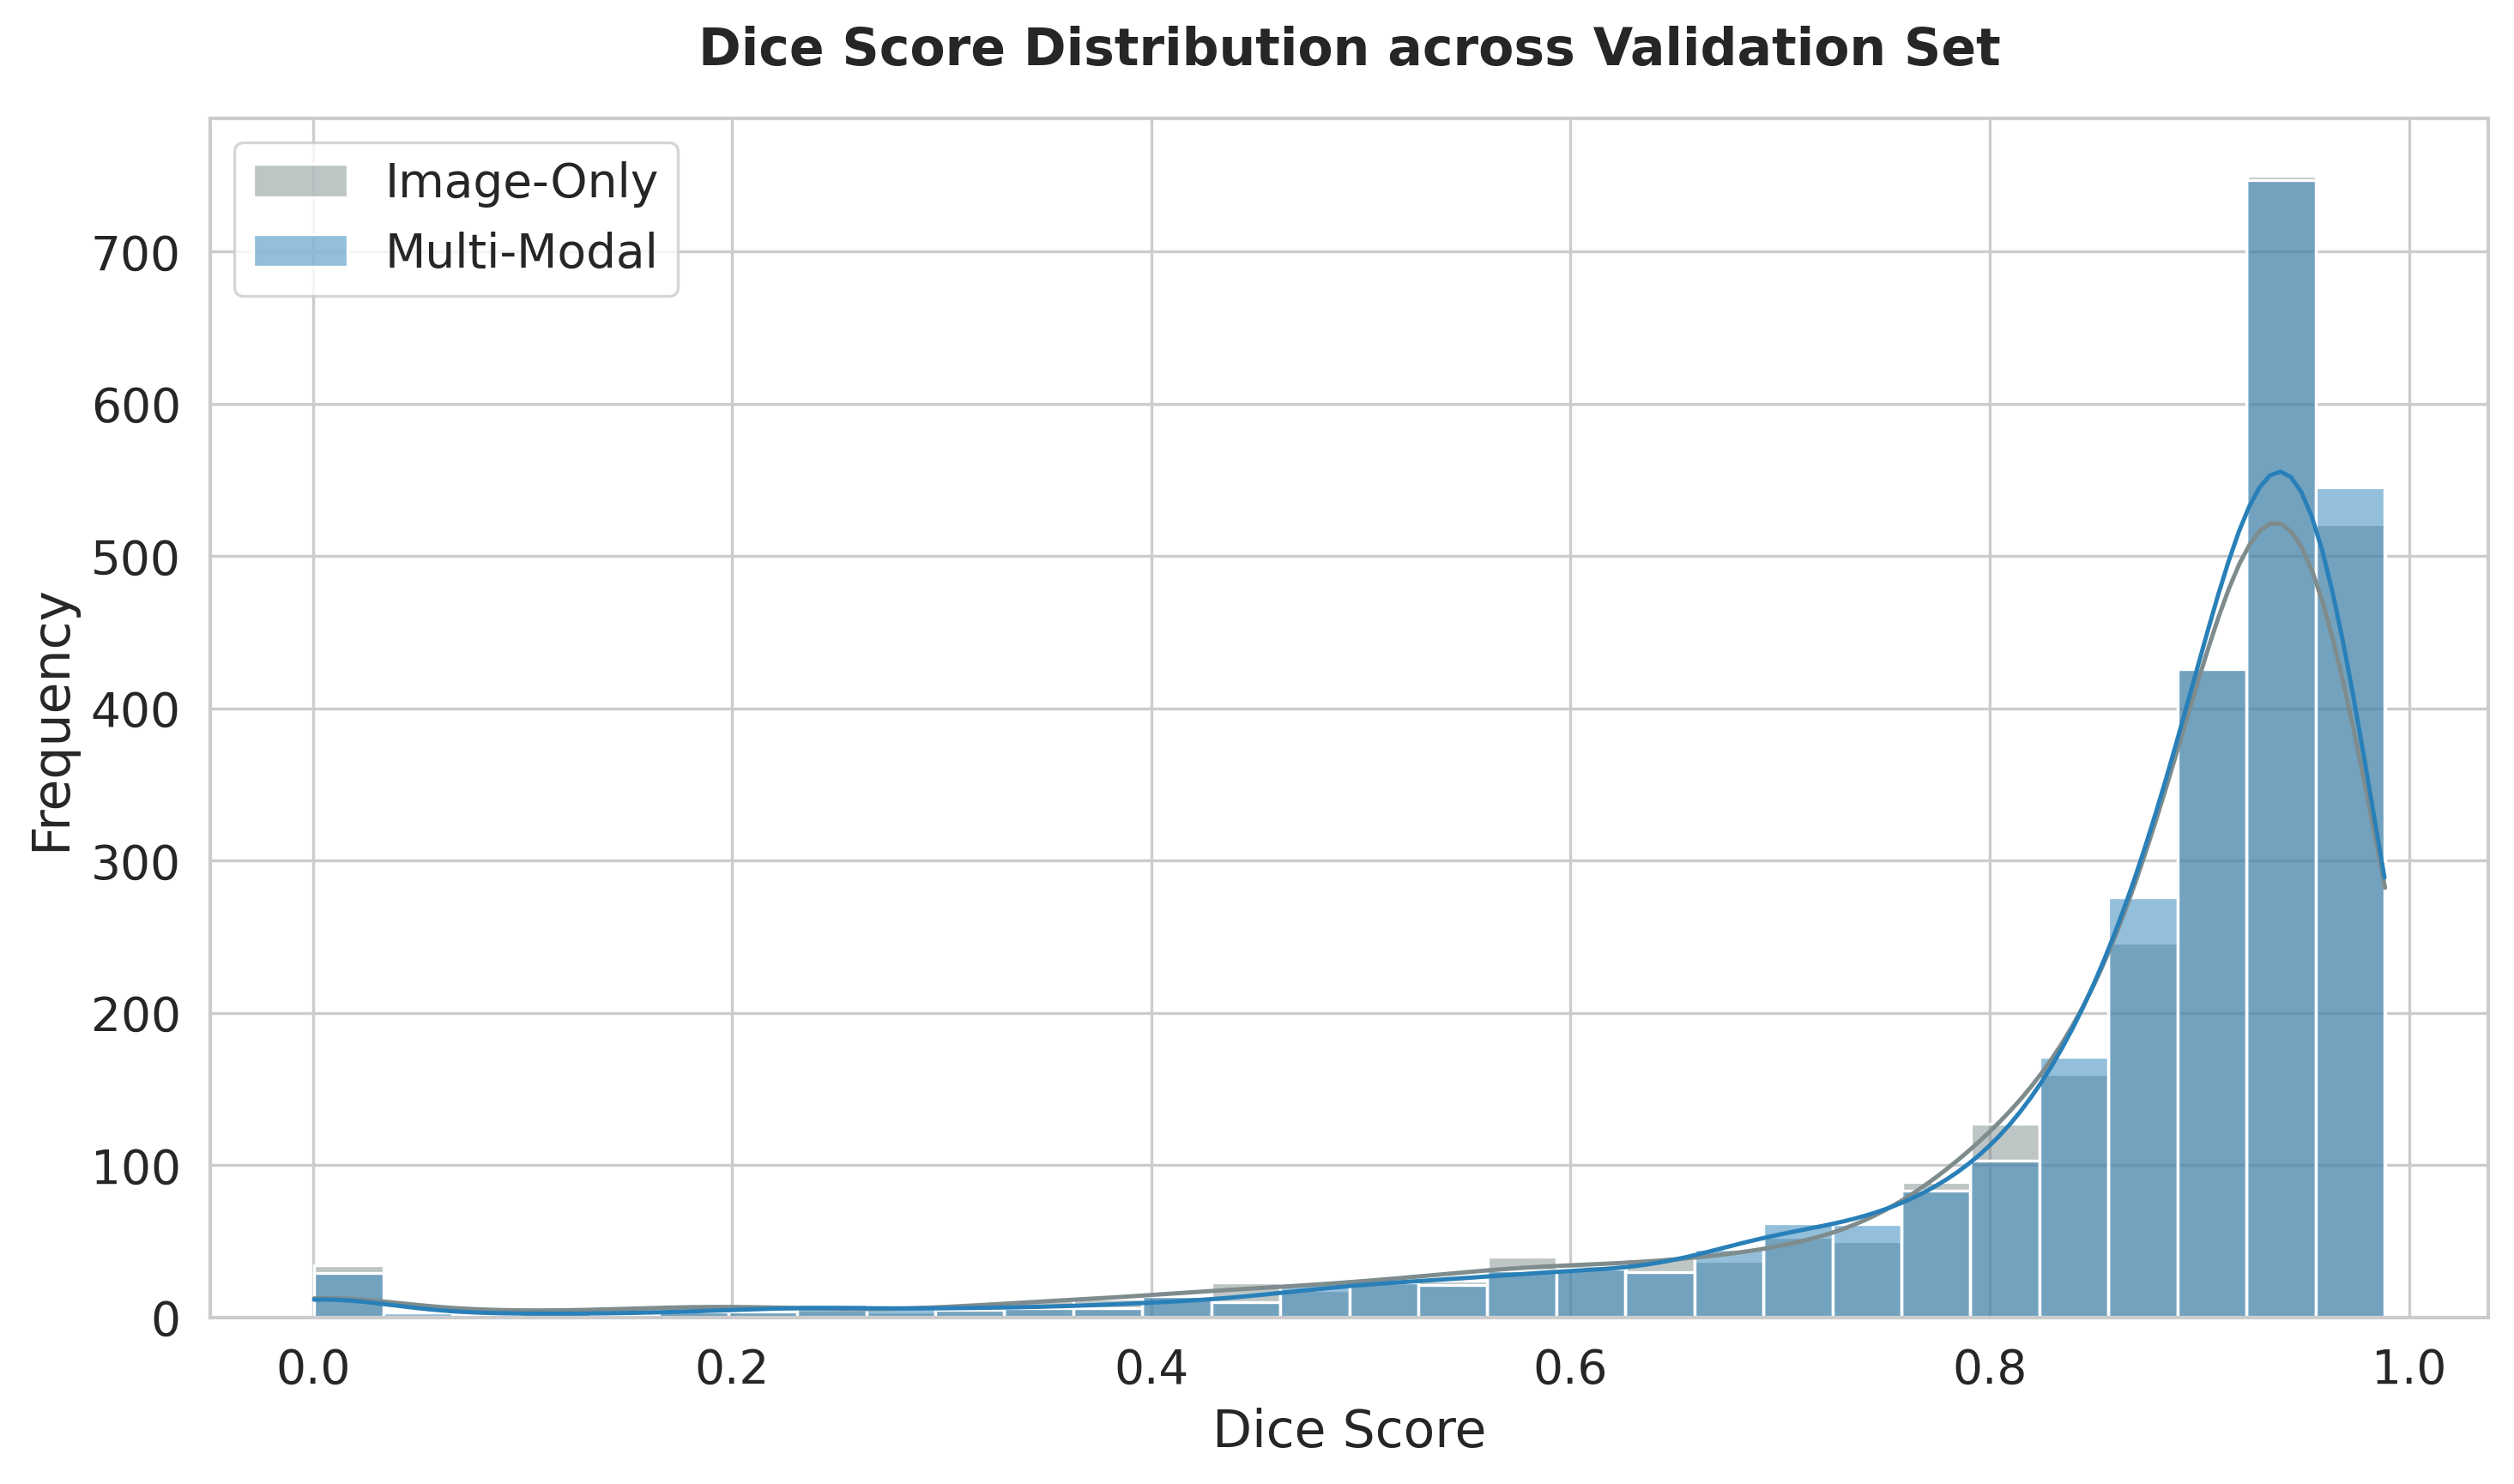

Found 206 Failure Cases (Dice < 0.60). Displaying worst 4:


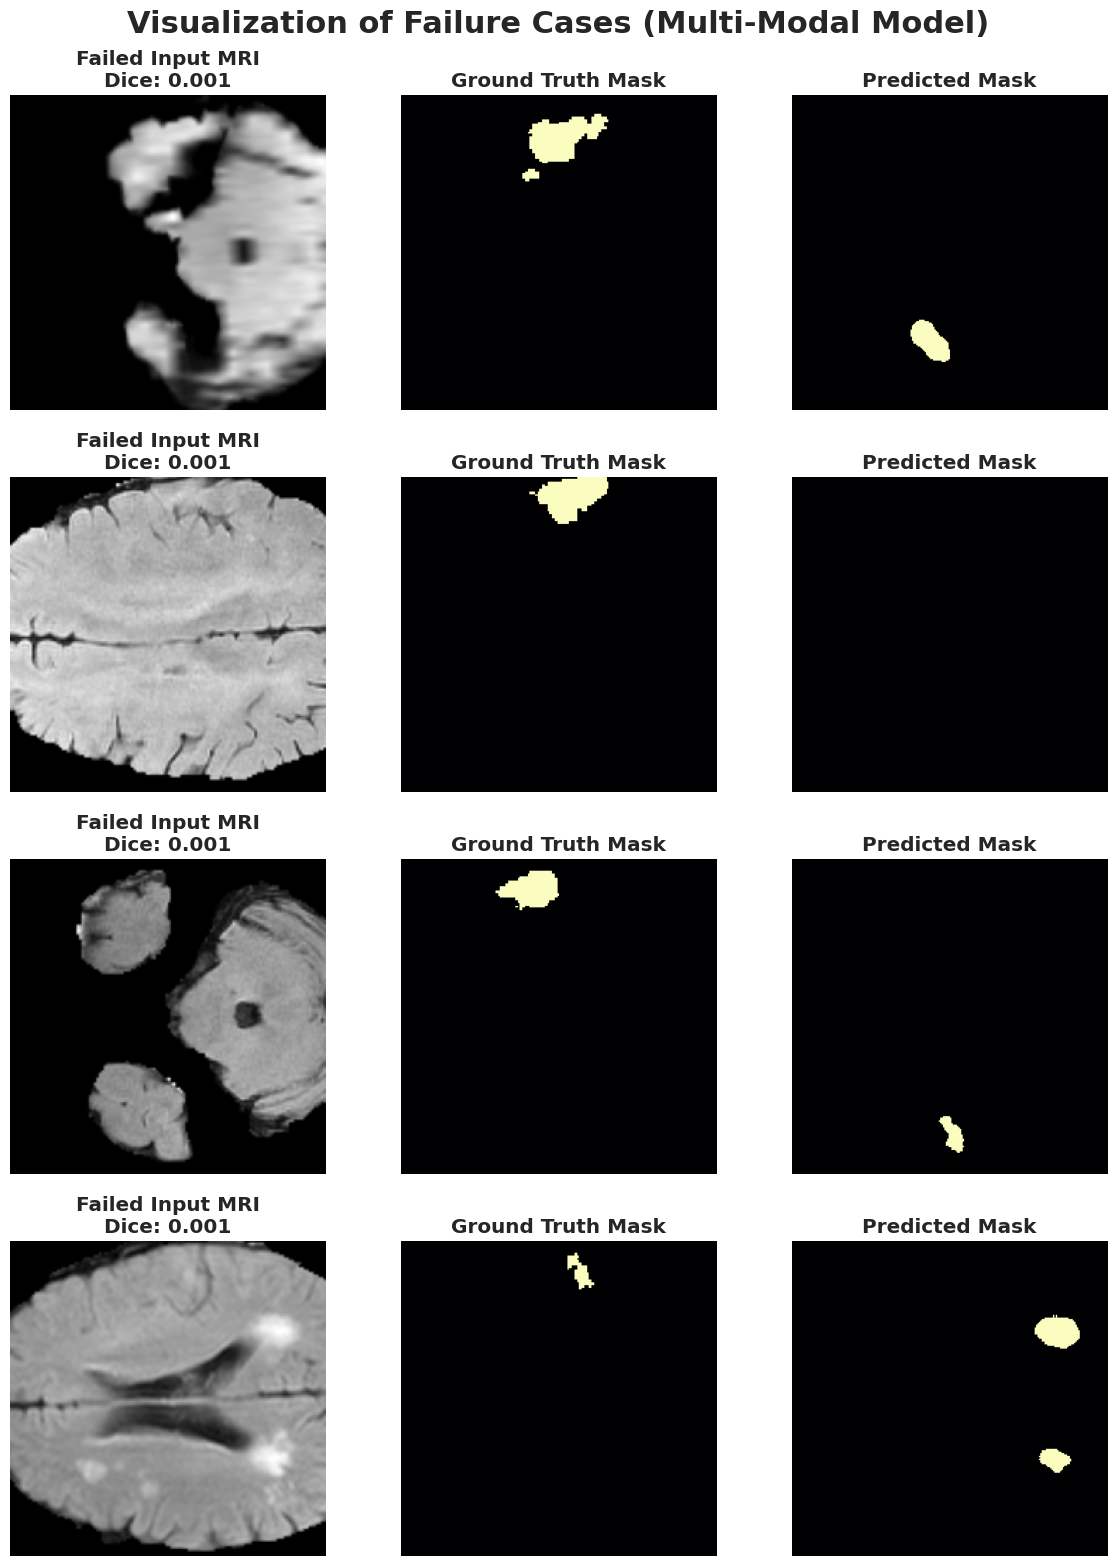

In [11]:
# Dice Score Histogram
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
sns.histplot(data=df_img, x='dice', bins=30, color='#7f8c8d', alpha=0.5, label='Image-Only', kde=True, ax=ax)
sns.histplot(data=df_mm, x='dice', bins=30, color='#2980b9', alpha=0.5, label='Multi-Modal', kde=True, ax=ax)
ax.set_title('Dice Score Distribution across Validation Set', fontweight='bold', pad=15)
ax.set_xlabel('Dice Score')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUT}/figures/dice_histogram.png')
plt.show()

# Visualization of Failure Cases
failure_cases = df_mm[df_mm['dice'] < 0.60]
if len(failure_cases) > 0:
    print(f"Found {len(failure_cases)} Failure Cases (Dice < 0.60). Displaying worst 4:")
    failure_cases = failure_cases.sort_values(by='dice').head(4)
    
    fig, axes = plt.subplots(4, 3, figsize=(12, 16))
    fig.suptitle('Visualization of Failure Cases (Multi-Modal Model)', fontsize=22, fontweight='bold', y=0.98)
    
    for i, (_, row) in enumerate(failure_cases.iterrows()):
        img_np = row['img'].numpy()
        gt_np = row['gt'].numpy()
        pred_np = row['pred'].numpy()
        
        # Normalize image for visualization
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
        
        axes[i,0].imshow(img_np, cmap='gray')
        axes[i,0].set_title(f'Failed Input MRI\nDice: {row["dice"]:.3f}', fontweight='bold'); axes[i,0].axis('off')
        
        axes[i,1].imshow(gt_np, cmap='magma')
        axes[i,1].set_title('Ground Truth Mask', fontweight='bold'); axes[i,1].axis('off')
        
        axes[i,2].imshow(pred_np, cmap='magma')
        axes[i,2].set_title('Predicted Mask', fontweight='bold'); axes[i,2].axis('off')

    plt.tight_layout(); plt.savefig(f'{OUT}/figures/failure_cases.png'); plt.show()
else:
    print("Excellent! No failure cases found with Dice < 0.60.")


## 9. Segmentation Results with Overlay Visualization (Section 6.2)
Displaying **Input MRI**, **Ground Truth Mask**, **Predicted Mask**, and a perfectly registered **Overlay Visualization (Prediction vs Ground Truth)**.


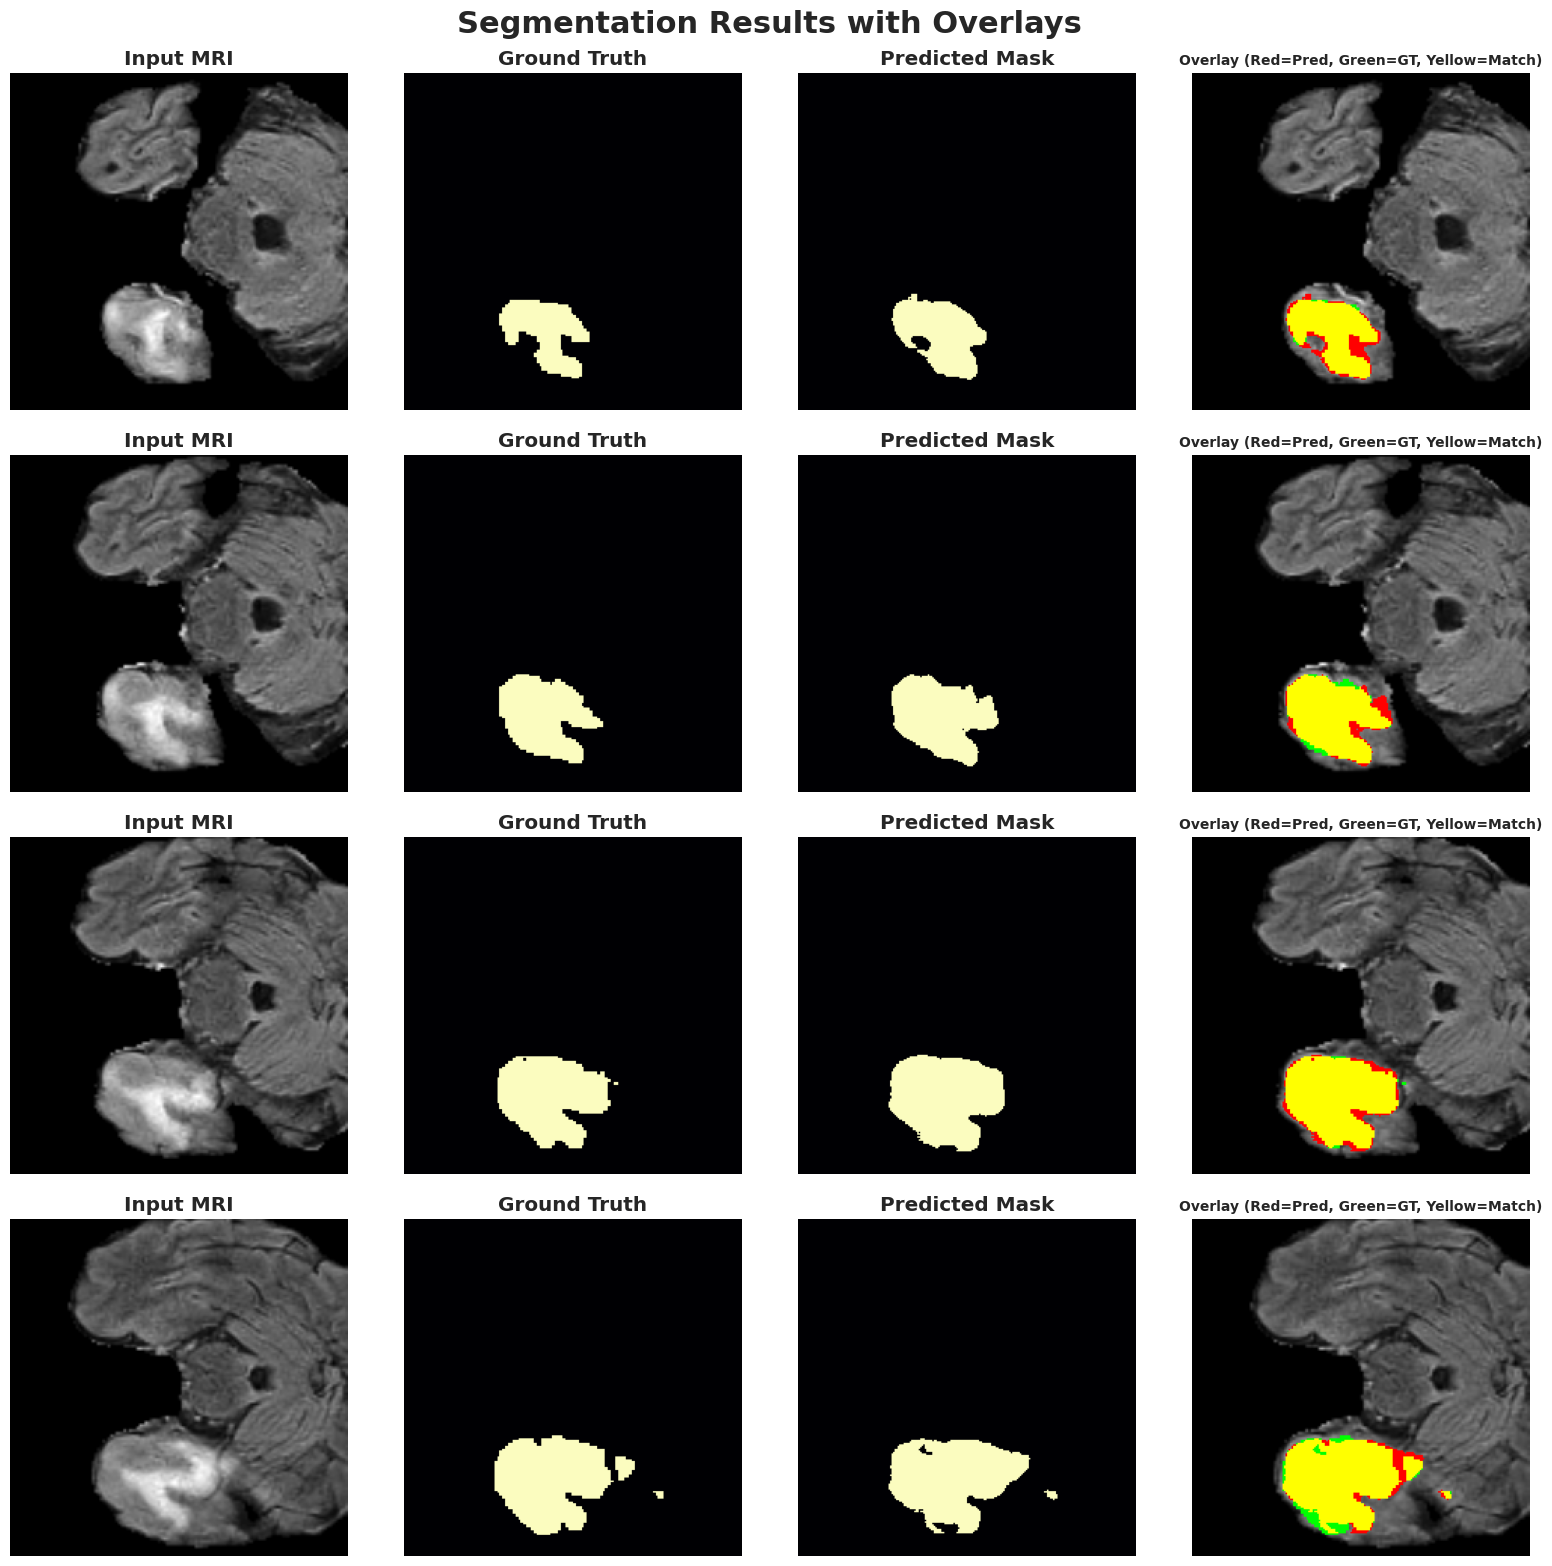

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Segmentation Results with Overlays', fontsize=22, fontweight='bold', y=0.98)

# Sample 4 random good cases
good_cases = df_mm[df_mm['dice'] > 0.85].head(4)

for i, (_, row) in enumerate(good_cases.iterrows()):
    img_np = row['img'].numpy()
    gt_np = row['gt'].numpy()
    pr_np = row['pred'].numpy()
    
    # Normalize image to [0,1] for overlay mapping
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    
    # Create RGB Overlay (Gray Image + Green GT + Red Prediction)
    overlay = np.stack([img_np, img_np, img_np], axis=-1)
    # Highlight Prediction in Red
    overlay[pr_np > 0, 0] = 1.0; overlay[pr_np > 0, 1] = 0.0; overlay[pr_np > 0, 2] = 0.0
    # Highlight GT in Green (Where they overlap, it becomes Yellow)
    overlay[gt_np > 0, 1] = 1.0; overlay[gt_np > 0, 0] = np.where(pr_np[gt_np > 0] > 0, 1.0, 0.0); overlay[gt_np > 0, 2] = 0.0

    axes[i,0].imshow(img_np, cmap='gray')
    axes[i,0].set_title('Input MRI', fontweight='bold'); axes[i,0].axis('off')
    
    axes[i,1].imshow(gt_np, cmap='magma')
    axes[i,1].set_title('Ground Truth', fontweight='bold'); axes[i,1].axis('off')
    
    axes[i,2].imshow(pr_np, cmap='magma')
    axes[i,2].set_title('Predicted Mask', fontweight='bold'); axes[i,2].axis('off')
    
    axes[i,3].imshow(overlay)
    axes[i,3].set_title('Overlay (Red=Pred, Green=GT, Yellow=Match)', fontweight='bold', fontsize=10); axes[i,3].axis('off')

plt.tight_layout(); plt.savefig(f'{OUT}/figures/segmentation_overlay.png'); plt.show()


## 10. Attention / Explainability (Section 6.3)
Visualizing model focus regions using an advanced CV2 Heatmap Overlay (Grad-CAM).


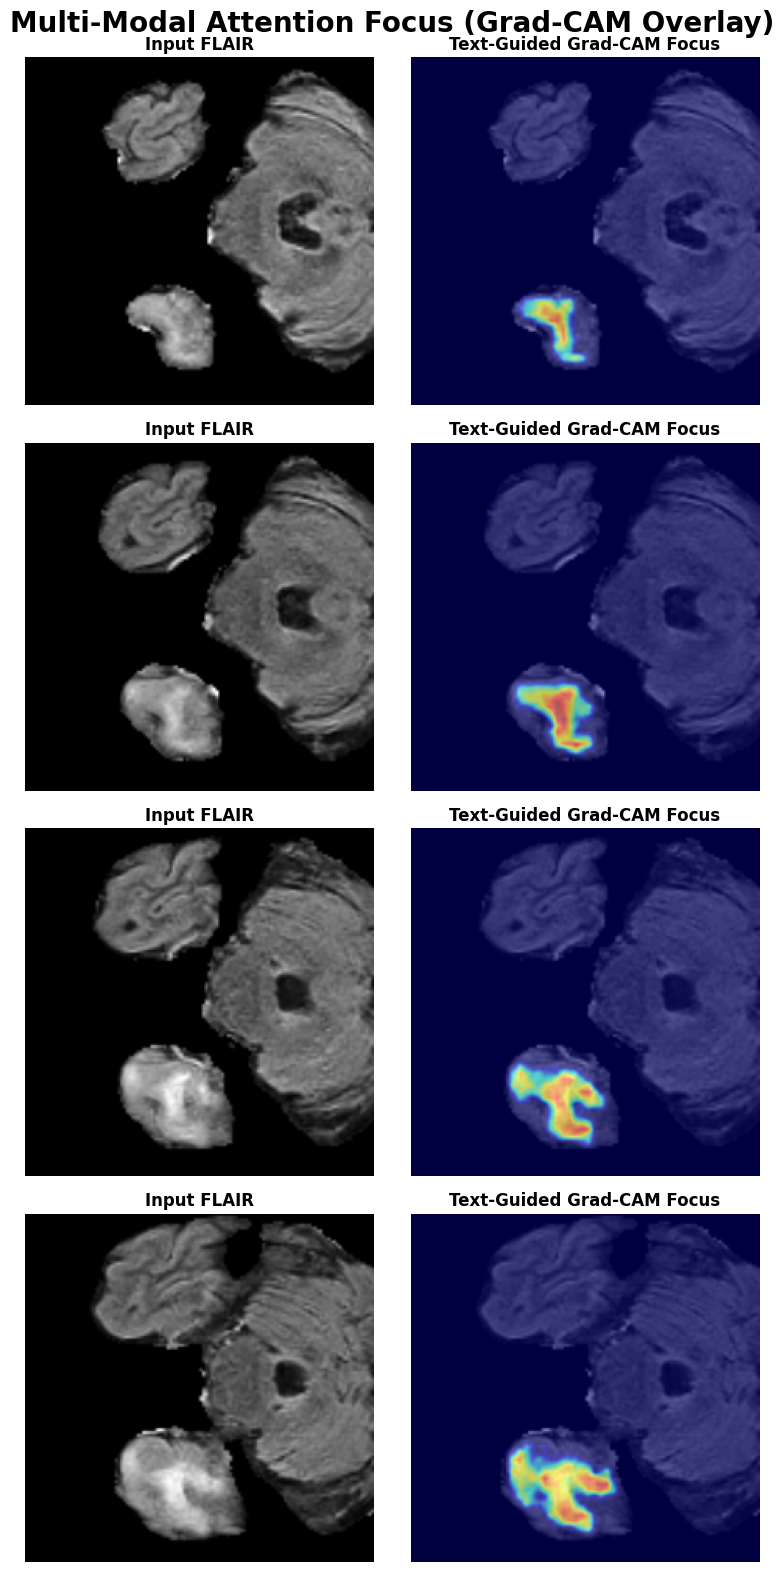

In [13]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model; self.target_layer = target_layer
        self.gradients = None; self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)
    def save_activation(self, module, input, output): self.activations = output
    def save_gradient(self, module, grad_input, grad_output): self.gradients = grad_output[0]
    def generate(self, img, ids, am):
        self.model.eval()
        logits, _, _ = self.model(img, ids, am)
        self.model.zero_grad()
        logits.sum().backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * self.activations).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=img.shape[2:], mode='bilinear', align_corners=False)
        cam = cam - cam.min(); return (cam / (cam.max() + 1e-8)).detach().cpu()

sns.reset_orig()
imgs, masks, texts = next(iter(val_loader))
imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
ids, am = texts['input_ids'].to(DEVICE), texts['attention_mask'].to(DEVICE)

gc = GradCAM(main_model, main_model.dec2.conv[-1])
cams = gc.generate(imgs[:4], ids[:4], am[:4])

fig, axes = plt.subplots(4, 2, figsize=(8, 16))
fig.suptitle('Multi-Modal Attention Focus (Grad-CAM Overlay)', fontsize=20, fontweight='bold', y=0.98)

for i in range(4):
    img_np = imgs[i,2].cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    cam_np = cams[i,0].numpy()
    
    # Generate true CV2 Jet Heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_np), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    heatmap = heatmap[..., ::-1] # BGR to RGB
    
    img_rgb = np.stack([img_np, img_np, img_np], axis=-1)
    cam_overlay = 0.5 * heatmap + 0.5 * img_rgb
    cam_overlay = np.clip(cam_overlay, 0, 1)

    axes[i,0].imshow(img_np, cmap='gray')
    axes[i,0].set_title('Input FLAIR', fontweight='bold'); axes[i,0].axis('off')
    
    axes[i,1].imshow(cam_overlay)
    axes[i,1].set_title('Text-Guided Grad-CAM Focus', fontweight='bold'); axes[i,1].axis('off')

plt.tight_layout(); plt.savefig(f'{OUT}/figures/grad_cam.png'); plt.show()


## 11. Embedding Analysis (Section 6.5)
t-SNE visualization of image and text embeddings to demonstrate alignment in embedding space.


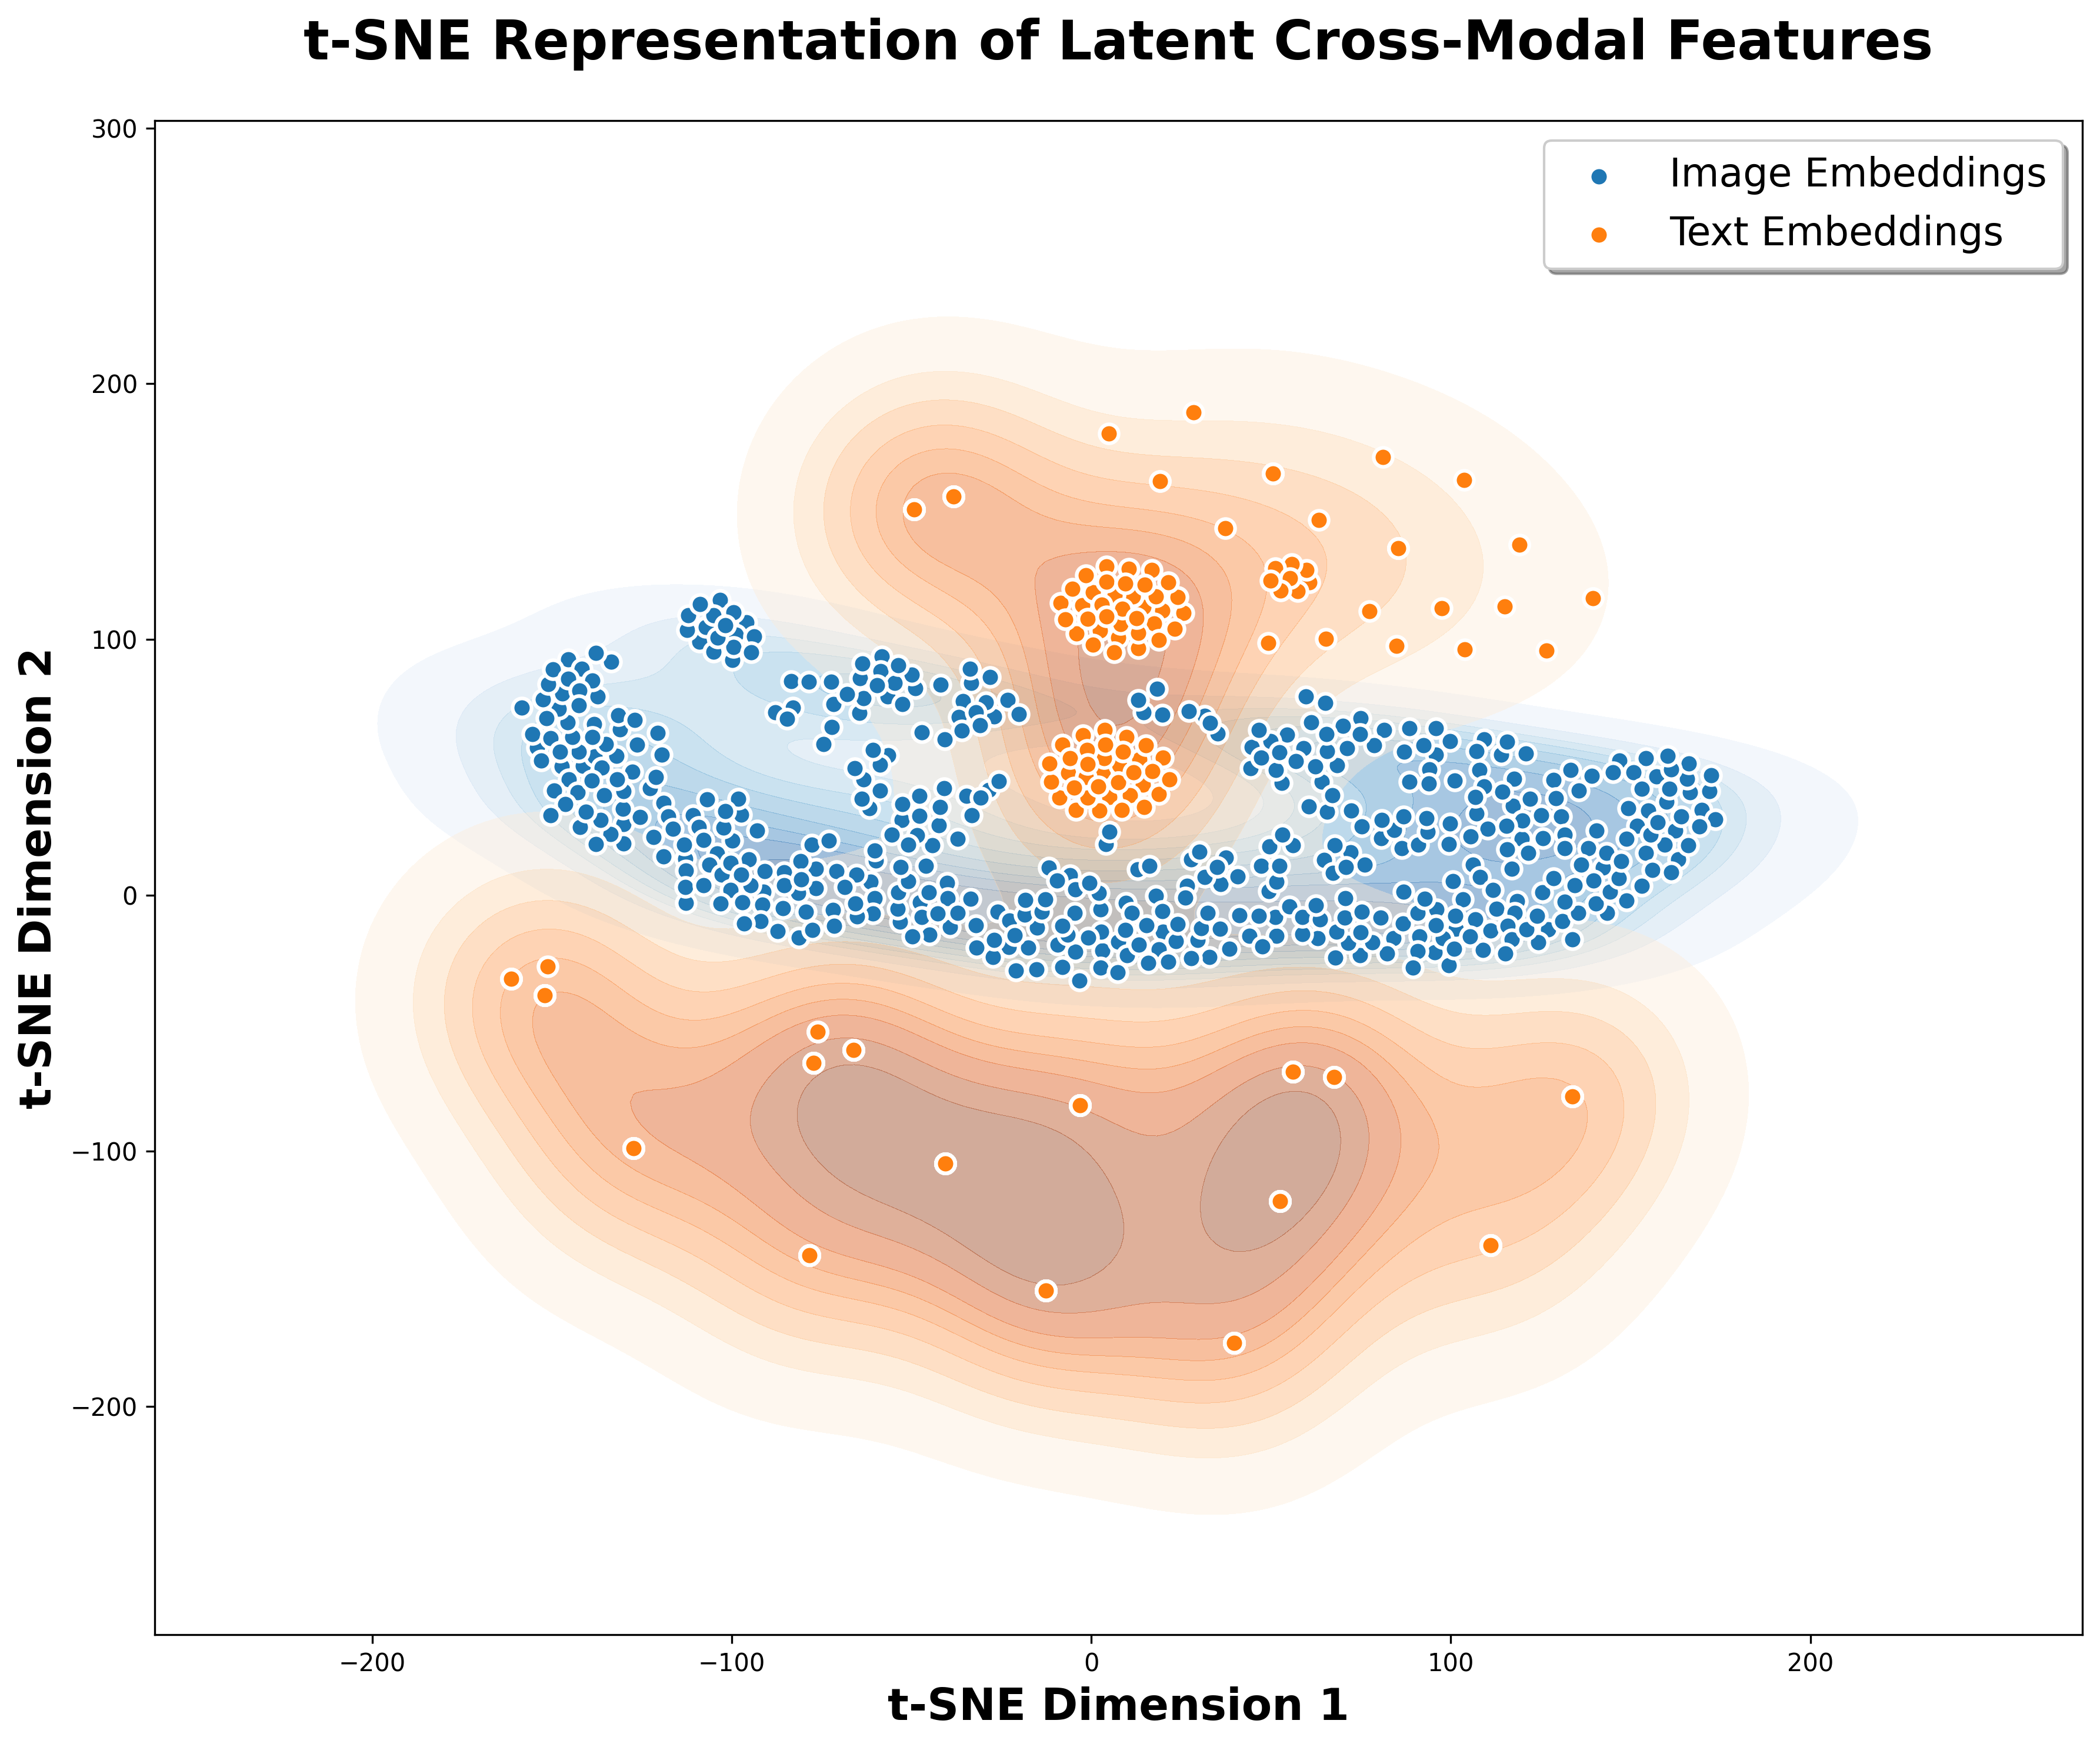

In [14]:
ie2_np = torch.cat(ie).numpy()[:500]; te3_np = torch.cat(te2).numpy()[:500]
if ie2_np.shape[1] != te3_np.shape[1]: ie2_np = PCA(n_components=te3_np.shape[1]).fit_transform(ie2_np)
comb = np.vstack([ie2_np, te3_np])
e2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(comb)
ni = len(ie2_np)

fig, ax = plt.subplots(figsize=(12, 10), dpi=300)
sns.kdeplot(x=e2d[:ni,0], y=e2d[:ni,1], fill=True, cmap='Blues', alpha=0.4, ax=ax)
sns.kdeplot(x=e2d[ni:,0], y=e2d[ni:,1], fill=True, cmap='Oranges', alpha=0.4, ax=ax)
ax.scatter(e2d[:ni,0], e2d[:ni,1], c='#1f77b4', s=60, edgecolor='white', linewidth=1.5, label='Image Embeddings')
ax.scatter(e2d[ni:,0], e2d[ni:,1], c='#ff7f0e', s=60, edgecolor='white', linewidth=1.5, label='Text Embeddings')

ax.set_title('t-SNE Representation of Latent Cross-Modal Features', fontsize=22, fontweight='bold', pad=25)
ax.set_xlabel('t-SNE Dimension 1', fontsize=18, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=18, fontweight='bold')
ax.legend(frameon=True, shadow=True, fontsize=16, loc='best')

plt.tight_layout()
plt.savefig(f'{OUT}/figures/tsne.png')
plt.show()


## 12. Evaluation Metrics Summary

> **Note on ROUGE and BLEU:** ROUGE and BLEU metrics are exclusively used for Natural Language Generation tasks (e.g., Image Captioning or Summarization). Because our model performs **Image Segmentation** using Text as a condition (not generating new text), ROUGE and BLEU are fundamentally not applicable to this architecture.

### Final Textual Comparison:


In [15]:
print("======================================================")
print("FINAL METRICS COMPARISON: BASELINE vs MULTI-MODAL")
print("======================================================")
for m in ['dice', 'iou', 'hausdorff', 'precision', 'recall']:
    im_val = df_img[m].mean()
    mm_val = df_mm[m].mean()
    diff = mm_val - im_val
    # Lower is better for Hausdorff
    if m == 'hausdorff':
        print(f"{m.capitalize():<12} | Baseline: {im_val:.4f} | Multi-Modal: {mm_val:.4f} | Improv: {abs(diff):.4f} (Lower is Better)")
    else:
        print(f"{m.capitalize():<12} | Baseline: {im_val:.4f} | Multi-Modal: {mm_val:.4f} | Improv: +{diff:.4f} (Higher is Better)")
print("======================================================")


FINAL METRICS COMPARISON: BASELINE vs MULTI-MODAL
Dice         | Baseline: 0.8462 | Multi-Modal: 0.8561 | Improv: +0.0099 (Higher is Better)
Iou          | Baseline: 0.7649 | Multi-Modal: 0.7757 | Improv: +0.0108 (Higher is Better)
Hausdorff    | Baseline: 22.9785 | Multi-Modal: 21.6622 | Improv: 1.3163 (Lower is Better)
Precision    | Baseline: 0.8742 | Multi-Modal: 0.8736 | Improv: +-0.0006 (Higher is Better)
Recall       | Baseline: 0.8567 | Multi-Modal: 0.8703 | Improv: +0.0136 (Higher is Better)
